<a href="https://colab.research.google.com/github/BU-Spark/ds-ciss-predictive-homlessness/blob/data-cleaning-feature/Regression_w_fixed_targets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

from google.colab import files

uploaded = files.upload()

Saving CISS_final_df2.csv to CISS_final_df2.csv


In [2]:
import pandas as pd
df = pd.read_csv('CISS_final_df2.csv')

df.head()


,CoC_Number,Year,weighted median income,weighted median rent,total population,CoC Name,Overall Homeless,Sheltered Total Homeless,Unsheltered Homeless,Overall Homeless Individuals,Overall Homeless People in Families,Poverty_Rate,Vacancy_Rate,Renter_Household_Rate,Cost_Burdened_Rate,Unemployment_Rate,Average Temperature,"Beds (ES, TH, SH)"
0,AK-500,2007,78328.533122,1062.638009,284267.0,Anchorage CoC,3.426356,2.962004,0.464352,2.448402,0.977954,8.298238,7.425172,40.858279,42.153397,7.583368,5.5,884.0
1,AK-500,2008,78328.533122,1062.638009,284267.0,Anchorage CoC,3.598729,3.239912,0.358818,2.444885,1.153845,8.298238,7.425172,40.858279,42.153397,7.583368,0.4,899.0
2,AK-500,2009,78328.533122,1062.638009,284267.0,Anchorage CoC,4.457077,3.904780,0.552298,2.888130,1.568948,8.298238,7.425172,40.858279,42.153397,7.583368,-0.2,877.0
3,AK-500,2010,78328.533122,1062.638009,284267.0,Anchorage CoC,4.330436,3.915333,0.415103,2.603186,1.727249,8.298238,7.425172,40.858279,42.153397,7.583368,1.5,990.0
4,AK-500,2011,80808.699781,1037.436470,287390.0,Anchorage CoC,4.255541,3.764919,0.490622,2.762796,1.492745,8.504627,7.073878,42.293547,42.845948,7.593841,7.0,1056.0


In [3]:
total_na = df.isna().sum().sum()
print(f"Total missing values: {total_na}")

Total missing values: 348


In [4]:
X = df.drop(['Overall Homeless', 'Sheltered Total Homeless', 'Unsheltered Homeless', 'Overall Homeless Individuals', 'Overall Homeless People in Families', 'CoC_Number',	'Year', 'CoC Name'], axis = 1)

targets = ['Overall Homeless', 'Sheltered Total Homeless', 'Unsheltered Homeless', 'Overall Homeless Individuals', 'Overall Homeless People in Families']

In [5]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt



Results for Overall Homeless:
  Train R-squared: 0.3336
  Train MAE: 0.9843
  Test R-squared: 0.2963
  Test MAE: 1.0862



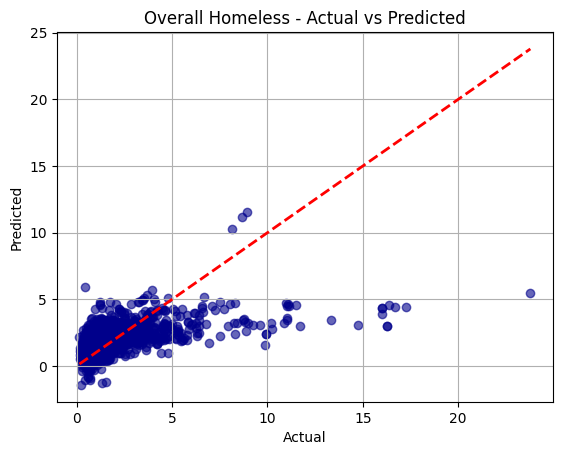

Results for Sheltered Total Homeless:
  Train R-squared: 0.4310
  Train MAE: 0.5315
  Test R-squared: 0.3852
  Test MAE: 0.5645



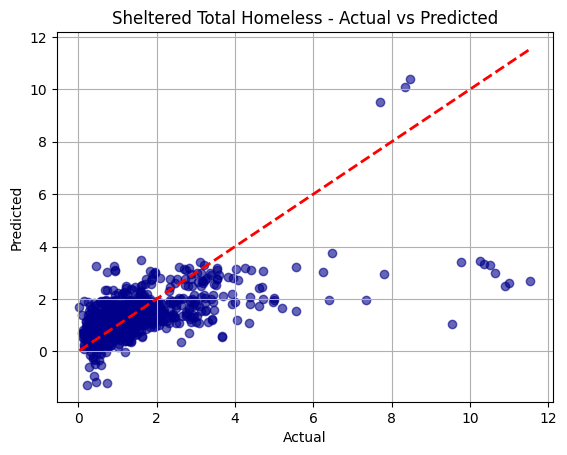

Results for Unsheltered Homeless:
  Train R-squared: 0.2063
  Train MAE: 0.6741
  Test R-squared: 0.2027
  Test MAE: 0.7447



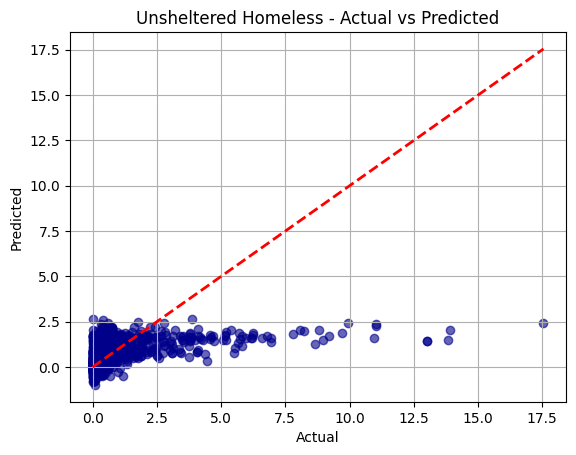

Results for Overall Homeless Individuals:
  Train R-squared: 0.3015
  Train MAE: 0.7285
  Test R-squared: 0.2739
  Test MAE: 0.8055



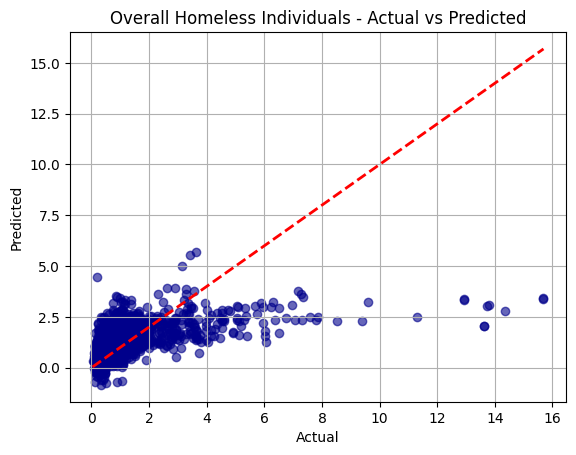

Results for Overall Homeless People in Families:
  Train R-squared: 0.2284
  Train MAE: 0.3624
  Test R-squared: 0.1905
  Test MAE: 0.4033



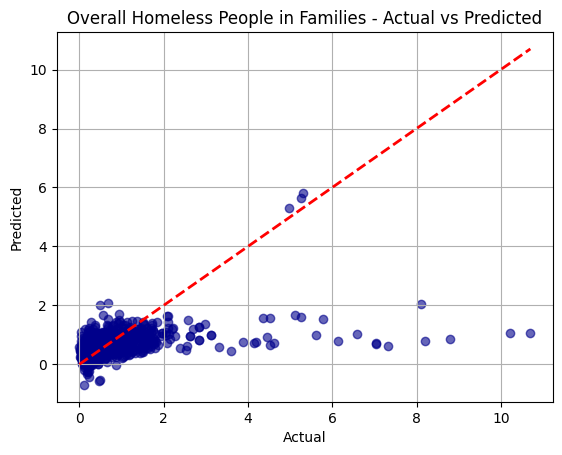

In [6]:
results = {}

X_train, X_test, y_train, y_test = train_test_split(X, df[targets], test_size=0.2, random_state=42)

for target in targets:
    # Step 1: Drop rows with NaNs in training features
    X_train_clean = X_train.dropna()
    y_train_clean = y_train[target].loc[X_train_clean.index]

    # Step 2: Train model
    model = LinearRegression()
    model.fit(X_train_clean, y_train_clean)

    # TRAIN performance
    y_train_pred = model.predict(X_train_clean)
    train_r2 = r2_score(y_train_clean, y_train_pred)
    train_mae = mean_absolute_error(y_train_clean, y_train_pred)

    # Step 3: Clean test data
    X_test_clean = X_test.dropna()
    y_test_clean = y_test[target].loc[X_test_clean.index]

    # Step 4: Predict and evaluate test
    y_pred = model.predict(X_test_clean)
    r2 = r2_score(y_test_clean, y_pred)
    mae = mean_absolute_error(y_test_clean, y_pred)

    results[target] = {
        'Train R-squared': train_r2,
        'Train MAE': train_mae,
        'Test R-squared': r2,
        'Test MAE': mae
    }

    # Print results
    print(f"Results for {target}:")
    print(f"  Train R-squared: {train_r2:.4f}")
    print(f"  Train MAE: {train_mae:.4f}")
    print(f"  Test R-squared: {r2:.4f}")
    print(f"  Test MAE: {mae:.4f}\n")

    plt.figure()
    plt.scatter(y_test_clean, y_pred, color='darkblue', alpha=0.6)
    plt.plot([y_test_clean.min(), y_test_clean.max()], [y_test_clean.min(), y_test_clean.max()], 'r--', lw=2)
    plt.title(f"{target} - Actual vs Predicted")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.grid(True)

    if target == "Sheltered Total Homeless":
      plt.savefig("sheltered_total_homeless.png")

    plt.show()


**WITHOUT BEDS**

In [7]:
X2 = df.drop(['Overall Homeless', 'Sheltered Total Homeless', 'Unsheltered Homeless', 'Overall Homeless Individuals', 'Overall Homeless People in Families', 'CoC_Number',	'Year','CoC Name', 'Beds (ES, TH, SH)' ], axis = 1)

targets = ['Overall Homeless', 'Sheltered Total Homeless', 'Unsheltered Homeless', 'Overall Homeless Individuals', 'Overall Homeless People in Families']

Results for Overall Homeless:
  Train R-squared: 0.3012
  Train MAE: 1.0121
  Test R-squared: 0.2635
  Test MAE: 1.1213



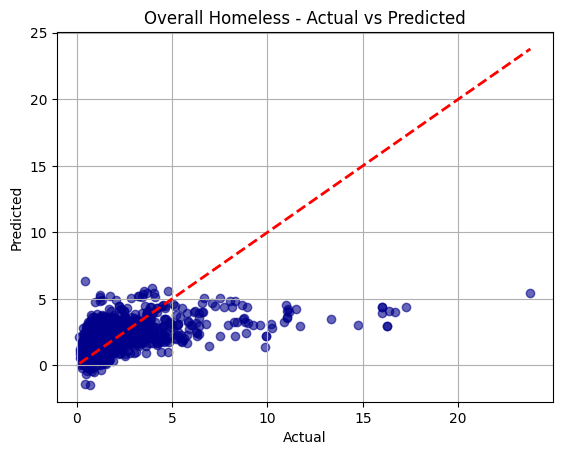

Results for Sheltered Total Homeless:
  Train R-squared: 0.3431
  Train MAE: 0.5767
  Test R-squared: 0.2936
  Test MAE: 0.6142



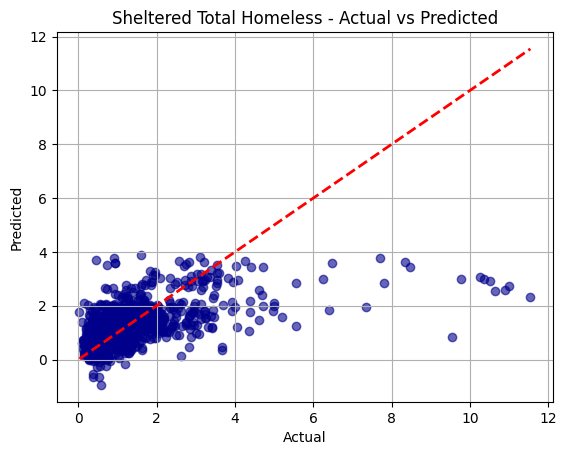

Results for Unsheltered Homeless:
  Train R-squared: 0.2063
  Train MAE: 0.6738
  Test R-squared: 0.2025
  Test MAE: 0.7446



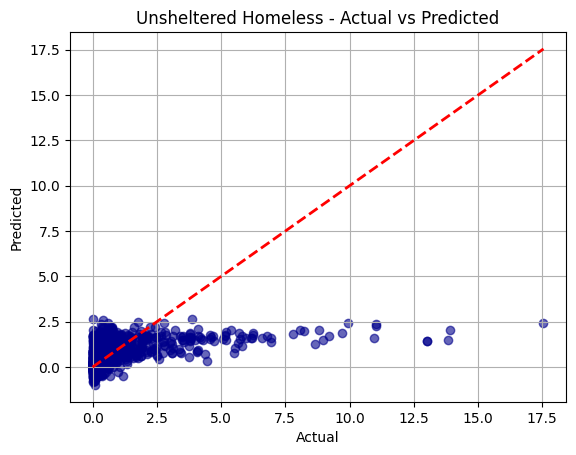

Results for Overall Homeless Individuals:
  Train R-squared: 0.2924
  Train MAE: 0.7339
  Test R-squared: 0.2641
  Test MAE: 0.8127



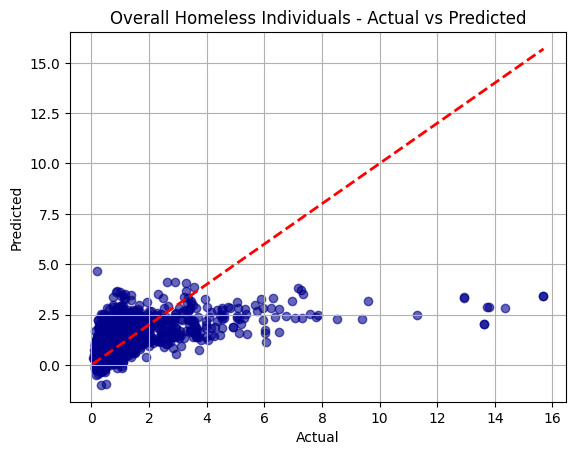

Results for Overall Homeless People in Families:
  Train R-squared: 0.1590
  Train MAE: 0.3843
  Test R-squared: 0.1247
  Test MAE: 0.4282



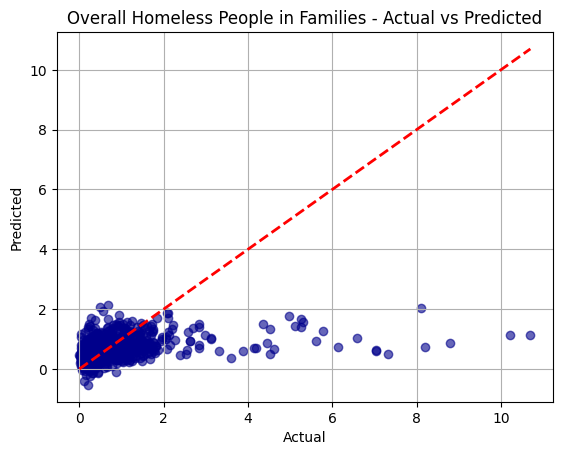

In [8]:
results = {}

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, df[targets], test_size=0.2, random_state=42)

for target in targets:
    # Step 1: Drop rows with NaNs in training features
    X2_train_clean = X2_train.dropna()
    y2_train_clean = y2_train[target].loc[X2_train_clean.index]

    # Step 2: Train model
    model = LinearRegression()
    model.fit(X2_train_clean, y2_train_clean)

    # TRAIN performance
    y2_train_pred = model.predict(X2_train_clean)
    train_r2 = r2_score(y2_train_clean, y2_train_pred)
    train_mae = mean_absolute_error(y2_train_clean, y2_train_pred)

    # Step 3: Clean test data
    X2_test_clean = X2_test.dropna()
    y2_test_clean = y2_test[target].loc[X2_test_clean.index]

    # Step 4: Predict and evaluate test
    y2_pred = model.predict(X2_test_clean)
    r2 = r2_score(y2_test_clean, y2_pred)
    mae = mean_absolute_error(y2_test_clean, y2_pred)

    results[target] = {
        'Train R-squared': train_r2,
        'Train MAE': train_mae,
        'Test R-squared': r2,
        'Test MAE': mae
    }

    # Print results
    print(f"Results for {target}:")
    print(f"  Train R-squared: {train_r2:.4f}")
    print(f"  Train MAE: {train_mae:.4f}")
    print(f"  Test R-squared: {r2:.4f}")
    print(f"  Test MAE: {mae:.4f}\n")

    plt.figure()
    plt.scatter(y2_test_clean, y2_pred, color='darkblue', alpha=0.6)
    plt.plot([y2_test_clean.min(), y2_test_clean.max()], [y2_test_clean.min(), y2_test_clean.max()], 'r--', lw=2)
    plt.title(f"{target} - Actual vs Predicted")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.grid(True)

    if target == "Overall Homeless":
      plt.savefig("Overall_Homeless.png")

    plt.show()



In [9]:

summary_table = pd.DataFrame({
    'Target': list(results.keys()),
    'Test R-squared': [round(results[target]['Test R-squared'], 4) for target in results],
    'Test MAE': [round(results[target]['Test MAE'], 2) for target in results]
})

print(summary_table)


                                Target  Test R-squared  Test MAE
0                     Overall Homeless          0.2635      1.12
1             Sheltered Total Homeless          0.2936      0.61
2                 Unsheltered Homeless          0.2025      0.74
3         Overall Homeless Individuals          0.2641      0.81
4  Overall Homeless People in Families          0.1247      0.43


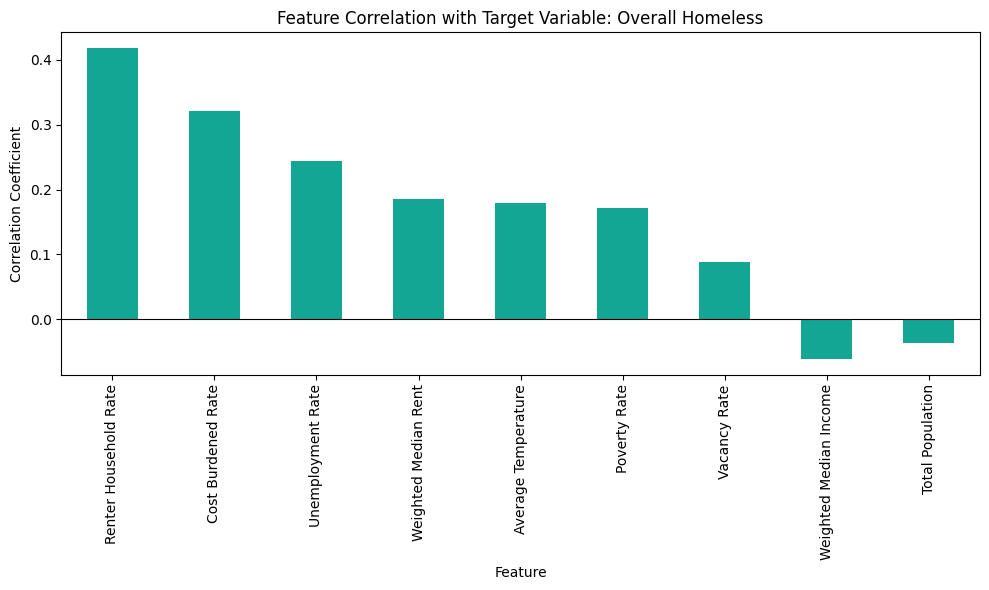

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

columns_to_drop = [
    'Overall Homeless',
    'Sheltered Total Homeless',
    'Unsheltered Homeless',
    'Overall Homeless Individuals',
    'Overall Homeless People in Families',
    'CoC_Number',
    'Year',
    'CoC Name',
    'Beds (ES, TH, SH)'
]

features_df = df.drop(columns=columns_to_drop)

features_df['Overall Homeless'] = df['Overall Homeless']

corr_matrix = features_df.corr()

overall_homeless_corr = corr_matrix['Overall Homeless'].drop('Overall Homeless')

overall_homeless_corr = overall_homeless_corr.reindex(overall_homeless_corr.abs().sort_values(ascending=False).index)

overall_homeless_corr.index = overall_homeless_corr.index.str.replace('_', ' ').str.title()

plt.figure(figsize=(10, 6))
overall_homeless_corr.plot(kind='bar', color='#13a694')
plt.title('Feature Correlation with Target Variable: Overall Homeless')
plt.xlabel('Feature')
plt.ylabel('Correlation Coefficient')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

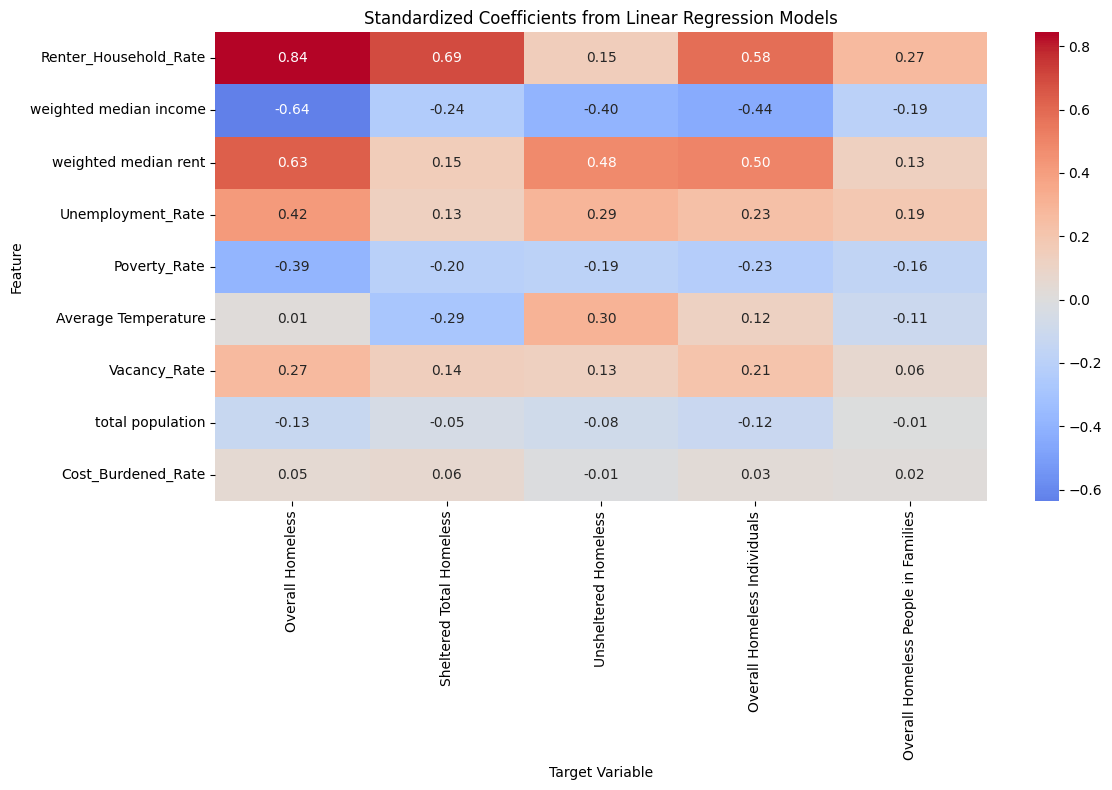

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

coef_matrix = pd.DataFrame()

# Loop through each target
for target in targets:
    # Clean data
    X_clean = X2_train.dropna()
    y_clean = y2_train[target].loc[X_clean.index]

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)

    # Fit model
    model = LinearRegression()
    model.fit(X_scaled, y_clean)

    # Store coefficients
    coef_matrix[target] = pd.Series(model.coef_, index=X_clean.columns)

# Optional: Sort rows (features) by absolute max influence across targets
coef_matrix['Max_Abs'] = coef_matrix.abs().max(axis=1)
coef_matrix = coef_matrix.sort_values(by='Max_Abs', ascending=False).drop(columns='Max_Abs')

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(coef_matrix, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title("Standardized Coefficients from Linear Regression Models")
plt.xlabel("Target Variable")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("Linear_Regression_Coefficient_Heatmap.png")
plt.show()
